**Exercise 10: Display the Analytical Solution and Exercise 11**

Run the following script using python: advection analytical.py (note: this is not a jupyter notebook)
• Change it into a notebook and show what happens when
1. you change the values of dx and c
2. you increase or decrease the parameter σ
• To learn more about animations with matplotlib: https://towardsdatascience.com/animations- with-matplotlib-d96375c5442c

# The advection equation
Numerical solution of the 1D advection problem
$$ \frac{\partial T}{\partial t} =  -c \frac{\partial T}{\partial x}$$ 
using an explicit forward in time, centred in space scheme

$T(x,t)$ represents the evolution of temperature distribution along the estuary over time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## User defined parameters

In [2]:
# problem parameters
c=0.25    # Advection speed [m s-1]
dx=150     # X resolution [m]
dt=200     # time step [s]
t0=0.       # initial time
tmax=0.1    # duration of simulation [days]
xmax=10.0e3 # length of the basin [m]

# Parameters of the initial temperature distribution
T0 = 15.        # baseline temperature [degC]
sigma = 2750.   # width at half amplitude [m]
A = 5.          # amplitude [degC]

## Initial function and grid specifications
The initial shape of the temperature distribution is a Gaussian peak function

In [3]:
# Spatial shape of the temperature disturbance
def Gaussian(x):
    y = T0+A*np.exp(-(x/sigma)**2)
    return y

The resulting space-time grid depends on the parameters above

In [4]:
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# X axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)             # number of grid points
T = np.zeros([IM,NT])     # the array holding the numerical solution 
print('Grid steps : ',IM)
print('Number of time steps : ',NT)
print('Timestep = ',dt,' s')
print('Max numerical speed DX/DT = ',dx/dt,' m/s')
print('Physical speed = ',c,' m/s')
print('Courant number = ',c*dt/dx)

Grid steps :  134
Number of time steps :  44
Timestep =  200  s
Max numerical speed DX/DT =  0.75  m/s
Physical speed =  0.25  m/s
Courant number =  0.3333333333333333


## Numerical solution
Note that this code stores the solution at all times in array T for educational purposes. This allows to plot the solution at the different time steps and see how it evolves.

*This method is very inefficient for any application because it uses a lot of memory. In modern computer codes only a few time records are hold in memory. The instantaneous solution is often temporarely stored for computing time averages and then discarded.*

This part of the code is the topic of some questions found in the lecture notes

In [5]:
# Compute the numerical solution using a time loop over the number of time steps
T[:,0] = Gaussian(x)    # initial condition

for n in range(NT-1):
    # Question 1
    T[0,n+1]  = T0
    T[-1,n+1] = T0
    # Question 2 and Question 3
    rhs = -c*(T[2:,n]-T[:-2,n])/(2.*dx) # L1
    T[1:-1,n+1] = T[1:-1,n] + rhs*dt    # L2

## Plot the result using a matplotlib animation
The animation below displays the evolution of the solution and compares it with the analytical solution

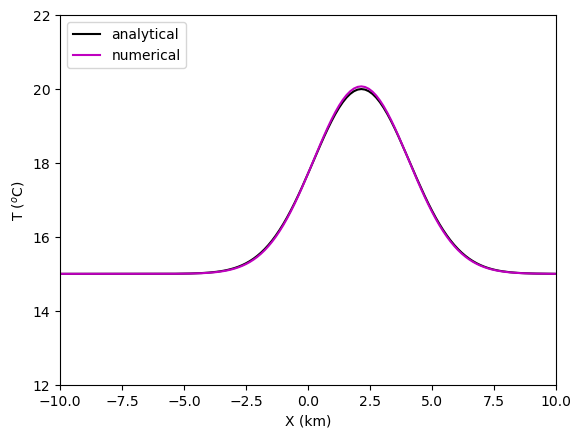

In [6]:
fig, ax = plt.subplots()
# set the axis limits
plt.axis([-xmax/1000, xmax/1000, T0-3, T0+7])
# first plot the initial conditions and set the line attributes
line, = ax.plot(x/1000., Gaussian(x),'k',label='analytical')
sol, = ax.plot(x/1000., T[:,0],'m',label='numerical')
ax.set_xlabel('X (km)')
ax.set_ylabel('T ($^o$C)')
plt.legend(loc='upper left')

def animate(i):
    t = t0 + i*dt
    line.set_ydata(Gaussian(x-c*t))  # update the analytical solution
    sol.set_ydata(T[:,i])  # update the numerical solution
    return line,sol,

# create the animation and loop (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=dt, blit=True, frames=NT, repeat=True)

# To save the animation, use e.g.
#ani.save("movieC1.mp4")
# or
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

# display the animation as a javascript object embedded in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

**Investigating lowering the Courant Number (not changing dt)**

In [ ]:
Selected configuration: σ = 2750 m, dx = 150 m, c = 0.20 m/s (Courant ≈ 0.27) because it minimises smearing, and keeps it clear of the faulting boundary.


# **Exercise 11**

**Claude AI Disclaimer** : I used AI to refine my answers and link my answers to these questions to the model runs I did in Exercise 10 PDF. 

**1. Look for the comment #Question 1 in the code. What do you think the next two lines do? [hint: see slide fr:PDE-problems]**

# Question 1
    T[0,n+1]  = T0
    T[-1,n+1] = T0

Establishes the boundary conditions, the temperature is fix at a left boundary of T[0] and a right boundary T[-1] to a baseline temperature of T0 (= 15.0 °C). So, this ensures that the boundaries remain undisburbed by the moving wave. From Exercise 10: when the physical speed is set high 2 m/s, the pulse travels 17.3 km over a 0.1-day run, colliding with the downstream boundary (situated at 10 km) partway through and causing severe distortion.

**2. Look for #Question 2 in the code. Which component of the numerical scheme is implemented in line #L1? What does line #L2
do?**

# Question 2 and Question 3
    rhs = -c*(T[2:,n]-T[:-2,n])/(2.*dx) # L1
calculates the spatial derviative (dT/dt), it computes gradient for all interior points by taking the difference between the node to the right (T[2:,n]) and the node to the left (T[:-2,n]), divided by $2\deltax.
    T[1:-1,n+1] = T[1:-1,n] + rhs*dt    # L2
implements the 'Forward time' integration, where it updates the temperature of the interior points for the next time step (n+1) by adding the rate of change (rhs * dt) to the current temperature (T[1:-1,n]). Together, L1 and L2 form the FTCS (Forward-Time Centered-Space) scheme.

**3. Look for #Question 3 in the code. Why the code does not perform the computation on all the elements of the array T, i.e.
T[:,n]?**

# Question 2 and Question 3
    rhs = -c*(T[2:,n]-T[:-2,n])/(2.*dx) # L1
    T[1:-1,n+1] = T[1:-1,n] + rhs*dt    # L2

The code updates the interior points (T[1:-1, n+1]) instead of the entire array (T[:, n+1]) because the Centered Space scheme requires adjacent nodes to the left and right, the Centered Space scheme (line #L1) requires a point to the left and a point to the right.

**4. Analysis of the numerical solution. How different is the numerical solution from the expected moving perturbation? What is the
possible reason?**

The numerical solution deviates from the expected analytical perturbation displaying distortion and smearing. 

Tracking the Courant number during testing revealed better-resolved solution.

Lowering the advection speed lowers the Courant number and noticeably reduces this distortion. 

The optimal way to minimize the distortion between the analytical and numerical solutions is to combine a moderate spatial resolution (dx = 150 m) with a low speed (0.20 m/s), yielding a stable Courant number of approximately 0.27.  


**5. The grid parameters determine the value of the Courant number and hence the stability. The spatial and temporal steps are
linked. More spatial resolution (smaller dx) means that dt must also decrease to maintain the same Courant number. However,
things are not so simple. The higher spatial resolution (which should theoretically increase the Courant number) also enhance the
capability to resolve the real gradients (see the previous slide to understand how C interacts with the difference between adjacent
points). If you increase the Courant number to 1 by halving dx, what does it happen? Now set dx = 500 m and dt = 100 s to
get C = 0.1; what do you see and how would you interpret it?**


Looking at Exercise 10:

Halving dx: If you decrease the spatial resolution too much without altering the time step, the Courant number spikes.Exercise 10 testing shows that dropping dx to 50 m causes the Courant number to reach 4.0.

At this massive Courant number, the simulation breaks down completely and becomes violently unstable.

Setting C = 0.1 (dx = 500 m, dt = 100 s): setting dx too large introduces heavy numerical diffusion. A moderate dx of 150 m is a  middle ground to capture the wave accurately without breaching stability thresholds

**6. The choice of the grid parameters also depend on the features that you want to resolve. Set the parameter σ = 1000 m (a
steeper wave). What do you have to do to recover the same degree of accuracy of the previous solution? (note that it takes
longer to generate the movie when you decrease the time step because NT increases and more frames are generated). Make
another copy of the original notebook and double the current speed. How would you explain the result?**

sigma = 2750 m causes minimized smearing. While, a sigma of 1000m will result in a narrow and steep wave. 

If the speed is doubled or increased strongly (e.g., pushing toward 1 m/s or 2 m/s), the Courant number increases at similar proportionality, casues the model to become more unstable. So, faster speeds means the physical distance the wave travels will extend massively up to 17.3 km at 2 m/s. To handle this, reduce the time step (dt) to stabilize the Courant number. 